In [1]:
# !pip install -U blobfile

# Using ABBA-LLM to predict the time series

In [ ]:
# install required packages 
%pip install -U bitsandbytes
%pip install -U fabba
%pip install -U transformers
%pip install -U peft
%pip install -U accelerate
%pip install -U trl 
%pip install datasets==2.16.0

In [1]:
# %%capture

import os
import argparse
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
from fABBA import JABBA
from qabba import QABBA 

import os
import pickle
from sklearn import preprocessing
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import accuracy_score
from src.preprocessing import encoders, vector_embed
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
import math
from datasets.dataset_dict import DatasetDict
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,HfArgumentParser,TrainingArguments,pipeline, logging
from peft import get_peft_model, LoraConfig, TaskType
from transformers import AutoTokenizer, DataCollatorWithPadding, DataCollatorForLanguageModeling
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training, get_peft_model
from trl import SFTTrainer
import evaluate
import numpy as np
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

from transformers import TrainingArguments, Trainer
import tiktoken
from tiktoken.load import load_tiktoken_bpe

import warnings

torch.cuda.empty_cache()

2024-12-12 09:21:52.269726: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-12 09:22:16.747857: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# !pip install qabba==0.1.4

%%capture
%pip install -U bitsandbytes
%pip install -U transformers
%pip install -U peft
%pip install -U accelerate
%pip install -U trl 
%pip install datasets==2.16.0### 0. Accelerator

Set up the Accelerator. I'm not sure if we really need this for a QLoRA given its [description](https://huggingface.co/docs/accelerate/v0.19.0/en/usage_guides/fsdp) (I have to read more about it) but it seems it can't hurt, and it's helpful to have the code for future reference. You can always comment out the accelerator if you want to try without.

In [3]:
from accelerate import FullyShardedDataParallelPlugin, Accelerator
from torch.distributed.fsdp.fully_sharded_data_parallel import FullOptimStateDictConfig, FullStateDictConfig

fsdp_plugin = FullyShardedDataParallelPlugin(
    state_dict_config=FullStateDictConfig(offload_to_cpu=True, rank0_only=False),
    optim_state_dict_config=FullOptimStateDictConfig(offload_to_cpu=True, rank0_only=False),
)

accelerator = Accelerator(fsdp_plugin=fsdp_plugin)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


### 1. Tokenization

Set up the tokenizer. Add padding on the left as it [makes training use less memory](https://ai.stackexchange.com/questions/41485/while-fine-tuning-a-decoder-only-llm-like-llama-on-chat-dataset-what-kind-of-pa).


In [4]:
warnings.filterwarnings("ignore")

data_template = {
    "text": [],
    "labels": [],
}


global batch_size
global model_tokenizer
global MAX_LENGTH

###############   Time Series Data   ###############
seq_len_pre = 168  # 96 -> 96;;; 168 -> 24, 48, 96
seq_len_post = 168  # 96 -> 96;;; 168 -> 24, 48, 96
lora_r = 16
data_name = 'ETTh1'
MAX_LENGTH_pre = seq_len_pre*7
MAX_LENGTH_post = seq_len_post*7
# llm_name = 'mistralai/Mistral-7B-Instruct-v0.1'
llm_name = 'starmpcc/Asclepius-Llama2-7B'

In [5]:
# tokenizer_path = "/home/kangchen/Chatbot/Psych_BioGPT/models/input/llama3/Meta-Llama-3-8B-Instruct-torch/tokenizer.model"
# mergeable_ranks = load_tiktoken_bpe(tokenizer_path)
# special_tokens = [
#             "<|begin_of_text|>",
#             "<|end_of_text|>",
#             "<|reserved_special_token_0|>",
#             "<|reserved_special_token_1|>",
#             "<|reserved_special_token_2|>",
#             "<|reserved_special_token_3|>",
#             "<|start_header_id|>",
#             "<|end_header_id|>",
#             "<|reserved_special_token_4|>",
#             "<|eot_id|>",  # end of turn
#         ] + [f"<|reserved_special_token_{i}|>" for i in range(5, 256 - 5)]
# vocab_list = load_tiktoken_bpe(tokenizer_path)
# model_tokenizer = tiktoken.Encoding(
#     name=Path(tokenizer_path).name,
#     pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+",
#     mergeable_ranks=vocab_list,
#     special_tokens={token: len(vocab_list) + i for i, token in enumerate(special_tokens)},
# )

# # 测试分词器编码和解码功能
# model_tokenizer.decode(model_tokenizer.encode("! #!"))

In [6]:
model_tokenizer = AutoTokenizer.from_pretrained(
    llm_name,
    model_max_length=(MAX_LENGTH_pre+MAX_LENGTH_post)*2,
    padding_side="right",
    truncation=True,
    add_eos_token=True)

model_tokenizer.padding_side = 'right'
model_tokenizer.pad_token = model_tokenizer.eos_token
print(len(model_tokenizer))

mistral_vocab = model_tokenizer.get_vocab()
vocab_list = list(mistral_vocab.keys())

32000


In [7]:
len(vocab_list)

32000

### 2. Load Dataset

Let's load a meaning representation dataset, and fine-tune Mistral on that. This is a great fine-tuning dataset as it teaches the model a unique form of desired output on which the base model performs poorly out-of-the box, so it's helpful to easily and inexpensively gauge whether the fine-tuned model has learned well. (Sources: [here](https://ragntune.com/blog/gpt3.5-vs-llama2-finetuning) and [here](https://www.anyscale.com/blog/fine-tuning-is-for-form-not-facts)) (In contrast, if you fine-tune on a fact-based dataset, the model may already do quite well on that, and gauging learning is less obvious / may be more computationally expensive.)

In [8]:

# Python program to convert a list to string
def listToString(s):
    # initialize an empty string
    str1 = ""
    # traverse in the string
    for ele in s:
        str1 += ele + ' '
    # return string
    return str1

# Python program to convert a list to string
def listToString_blank(s):
    # initialize an empty string
    str1 = ""
    # traverse in the string
    for ele in s:
        str1 += ele + ''
    # return string
    return str1

# Python program to convert a list to string
def stringToList(s):
    # initialize an empty string
    str1 = []
    # traverse in the string
    for ele in range(int(len(s)/2)):
        str1.append(s[ele*2])
    # return string
    return str1

def mean(arr):
    return sum(arr) / len(arr)

def cross_correlation(x, y):
    # Calculate means
    x_mean = mean(x)
    y_mean = mean(y)
    
    # Calculate numerator
    numerator = sum((a - x_mean) * (b - y_mean) for a, b in zip(x, y))
    
    # Calculate denominators
    x_sq_diff = sum((a - x_mean) ** 2 for a in x)
    y_sq_diff = sum((b - y_mean) ** 2 for b in y)
    denominator = math.sqrt(x_sq_diff * y_sq_diff)
    correlation = numerator / denominator
    
    return correlation


def find_keys_by_value(dictionary, value):
    return [key for key, val in dictionary.items() if val == value]


def find_values_by_key(dictionary, keys):
    return [dictionary[key] for key in keys]

In [9]:
scaler = StandardScaler()    ##   DONE the Test  
# scaler = MinMaxScaler()

###############   Loading data   ###############
if (data_name == 'ETTh1') or (data_name == 'ETTh2'):

    current_file = 'data/time-series-dataset/dataset/ETT-small/'
    df_raw = pd.read_csv(os.path.join(current_file, data_name + '.csv'))
    border1s = [0, 12 * 30 * 24 - seq_len_pre, 12 * 30 * 24 + 4 * 30 * 24 - seq_len_post]
    border2s = [12 * 30 * 24, 12 * 30 * 24 + 4 * 30 * 24, 12 * 30 * 24 + 8 * 30 * 24]
    
    #     qabba = JABBA(tol=0.000037, init='agg', alpha=0.000037, scl=3, verbose=0)  #  MinMaxScaler
    
#     qabba = JABBA(tol=0.0001117541, init='agg', alpha=0.0001117541, scl=3, verbose=0)
#     qabba = JABBA(tol=0.0000408066, init='agg', alpha=0.0000408066, scl=3, verbose=0)  #  StandardScaler -> ETTh1  len=24
#     qabba = JABBA(tol=0.000040838, init='agg', alpha=0.000040838, scl=3, verbose=0)  #  StandardScaler -> ETTh1  len=96
    qabba = JABBA(tol=0.000040837, init='agg', alpha=0.000040837, scl=3, verbose=0)  #  StandardScaler -> ETTh1  len=168

elif (data_name == 'ETTm1') or (data_name == 'ETTm2'):
    current_file = 'data/time-series-dataset/dataset/ETT-small/'

    df_raw = pd.read_csv(os.path.join(current_file, data_name+'.csv'))
    border1s = [0, 12 * 30 * 24 * 4 - seq_len, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4 - seq_len]
    border2s = [12 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 8 * 30 * 24 * 4]

elif (data_name == 'Weather'):
    current_file = 'data/time-series-dataset/dataset/ETT-small/'

    df_raw = pd.read_csv(os.path.join(current_file, data_name + '.csv'))
    border1s = [0, 6 * 30 * 24 * 6 - seq_len, 6 * 30 * 24 * 6 + 0 * 30 * 24 * 6 - seq_len]
    border2s = [6 * 30 * 24 * 6, 6 * 30 * 24 * 6 + 0 * 30 * 24 * 6, 6 * 30 * 24 * 6 + 6 * 30 * 24 * 6]

cols_data = df_raw.columns[1:]
df_data = df_raw[cols_data]



In [11]:
#############################################  Train Data  #############################################
train_data = df_data[border1s[0]:border2s[0]]
scaler.fit(train_data.values)
train_data_transformed = scaler.transform(train_data)

X_Train_data_patch = np.zeros([train_data_transformed.shape[0] - (seq_len_pre + seq_len_post), seq_len_pre, train_data_transformed.shape[1]], dtype=float)
Y_Train_data_patch = np.zeros([train_data_transformed.shape[0] - (seq_len_pre + seq_len_post), seq_len_post, train_data_transformed.shape[1]], dtype=float)
for i_data_patch in range(train_data_transformed.shape[0] - (seq_len_pre + seq_len_post)):
    X_Train_data_patch[i_data_patch, :, :] = train_data_transformed[i_data_patch:i_data_patch + seq_len_pre, :]
    Y_Train_data_patch[i_data_patch, :, :] = train_data_transformed[i_data_patch + seq_len_pre:i_data_patch + seq_len_pre + seq_len_post, :]

symbols_train_data = []
symbols_train_data = qabba.fit_transform(X_Train_data_patch, alphabet_set=vocab_list, llm_split='Pre')
reconstruction_train_data = qabba.inverse_transform(symbols_train_data)
train_data_same_shape = qabba.recast_shape(reconstruction_train_data)  # recast into original shape

symbols_train_target = []
symbols_train_target, params_train_target = qabba.transform(Y_Train_data_patch, llm_split='Post')
reconstruction_train_target = qabba.inverse_transform(symbols_train_target, params_train_target)
train_target_same_shape = qabba.recast_shape(reconstruction_train_target, recap_shape=Y_Train_data_patch.shape)  # recast into original shape

print('##############################################################')
print("The length of used symbols is:" + str(qabba.parameters.centers.shape[0]))

train_data_symbolic = []
for i_data in range(len(symbols_train_data)):
    train_data_symbolic.append(listToString(list(symbols_train_data[i_data])))

train_target_symbolic = []
for i_data in range(len(symbols_train_target)):
    train_target_symbolic.append(listToString(list(symbols_train_target[i_data])))

arranged_seq = np.random.randint(len(train_data_symbolic), size=int(len(train_data_symbolic) * 0.2))

val_data_symbolic = [train_data_symbolic[index] for index in arranged_seq]
val_target_symbolic = [train_target_symbolic[index] for index in arranged_seq]


data_TS = DatasetDict({
    'train': Dataset.from_dict({'text_outputs': train_target_symbolic, 'text_inputs': train_data_symbolic}),
    'val': Dataset.from_dict({'text_outputs': val_target_symbolic, 'text_inputs': val_data_symbolic}),
})

print('#############################  END  #################################')

The length of used symbols is: 31807
##############################################################
The length of used symbols is:31807
#############################  END  #################################


In [12]:
mistral_vocab = model_tokenizer.get_vocab()
vocab_list = list(mistral_vocab.keys())

alphabets_list_used = qabba.parameters.alphabets

added_tokens = []
for i_add_tokens in range(len(alphabets_list_used)):
    if alphabets_list_used[i_add_tokens] not in vocab_list:
        print(alphabets_list_used[i_add_tokens])
        added_tokens.append(alphabets_list_used[i_add_tokens])
#         model_tokenizer.add_special_tokens(alphabets_list_used[i_add_tokens])

model_tokenizer.add_special_tokens({'additional_special_tokens': added_tokens})

0

In [13]:
len(model_tokenizer)

32000

In [14]:
mistral_vocab = model_tokenizer.get_vocab()
vocab_list_redesigned = list(mistral_vocab.keys())

In [15]:
len(vocab_list_redesigned)

32000

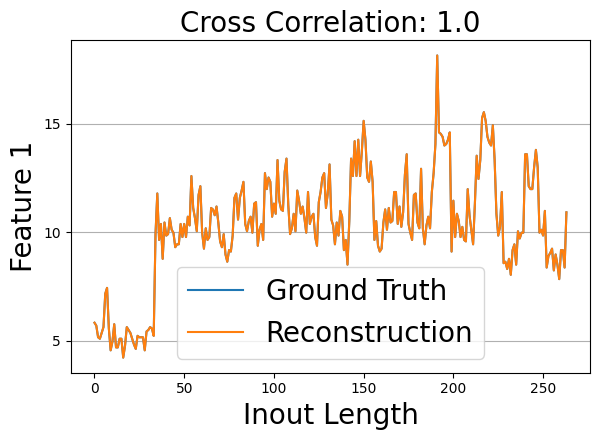

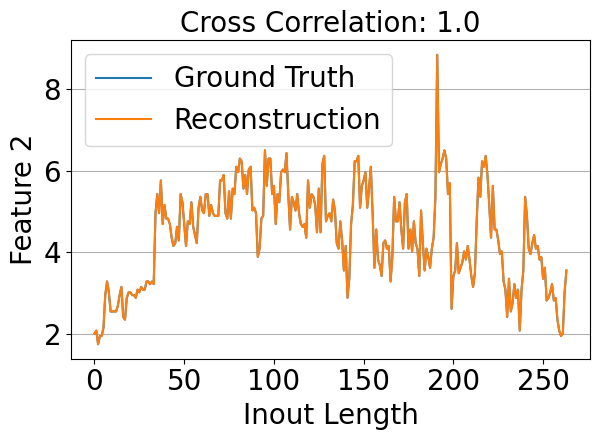

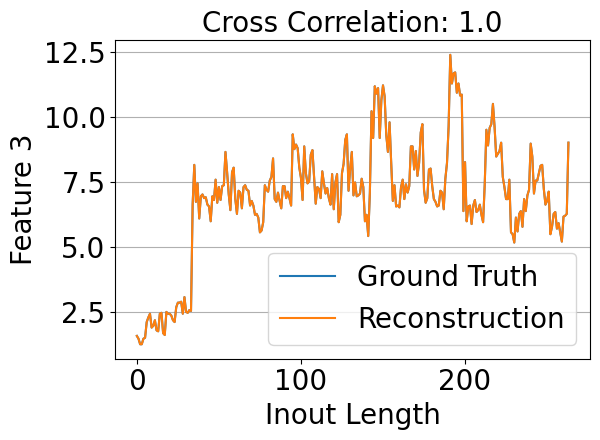

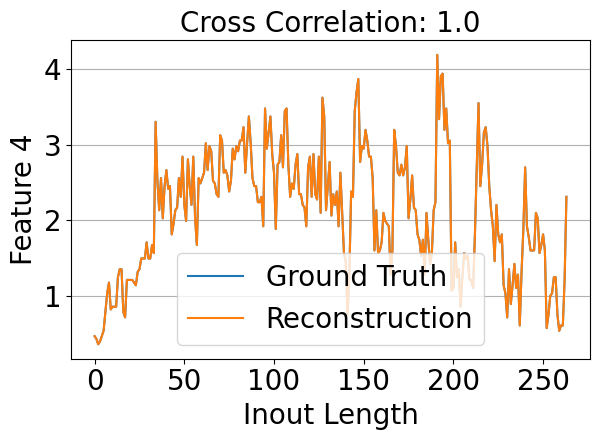

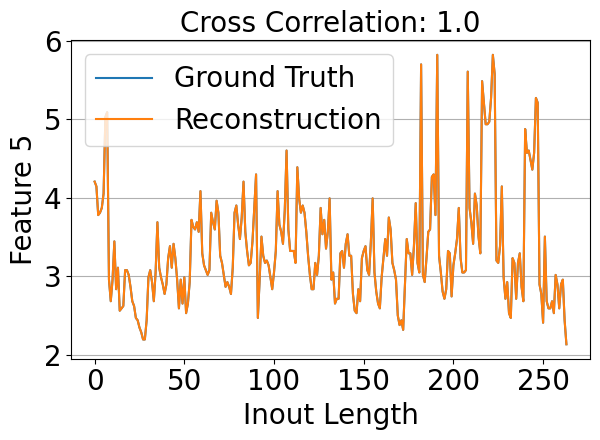

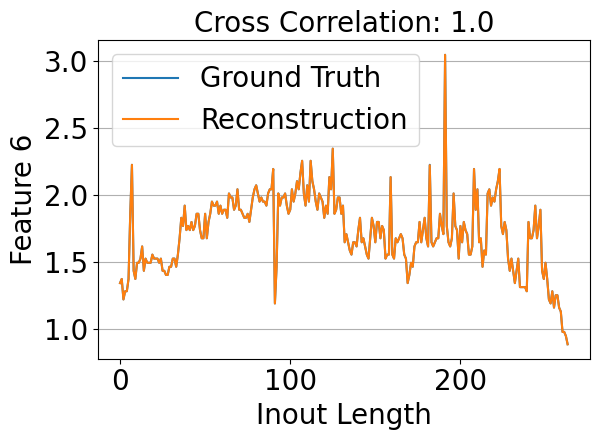

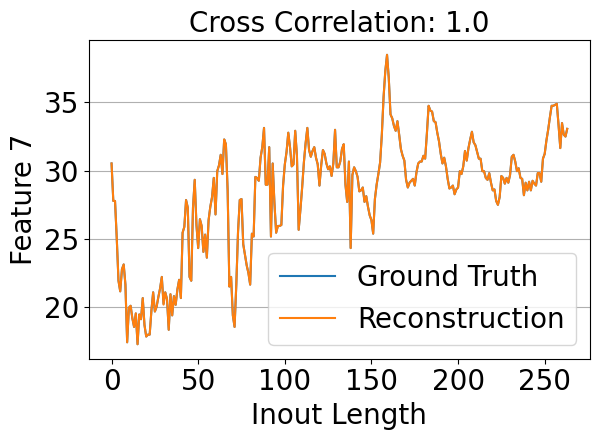

###############################
1.647544041149991e-06
0.0008202950432690751


In [16]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

train_length = 1

Y_recons_all = np.zeros(([train_length, 7 * seq_len_post]), dtype=float)
Y_true_all = np.zeros(([train_length, 7 * seq_len_post]), dtype=float)

for i_reconst in range(train_length):
    
   
    Y_true_pre = scaler.inverse_transform(X_Train_data_patch[i_reconst, :, :])
    Y_true_post = scaler.inverse_transform(Y_Train_data_patch[i_reconst, :, :])
    
    Y_recons_pre = scaler.inverse_transform(train_data_same_shape[i_reconst, :, :])
    Y_recons_post = scaler.inverse_transform(train_target_same_shape[i_reconst, :, :])

#     Y_recons = scaler.inverse_transform(train_reconst_same_shape[i_reconst, :, :])
#     Y_true = scaler.inverse_transform(np.transpose(data_patch[i_reconst, :, :]))

    
#     for i_plot in range(data.shape[1]):
    for i_plot in range(7):
#         plt.subplot(1, 7, i_plot+1)
        
        plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true_post[:, i_plot]), axis=0), label='Ground Truth')
        plt.plot(np.concatenate((Y_recons_pre[:, i_plot], Y_recons_post[:, i_plot]), axis=0), label='Reconstruction')

        Cross_Correlation = cross_correlation(np.concatenate((Y_true_pre[:, i_plot], Y_true_post[:, i_plot]), axis=0),np.concatenate((Y_recons_pre[:, i_plot], Y_recons_post[:, i_plot]), axis=0))
        plt.rcParams.update({'font.size': 20})
        plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

        plt.legend()
        plt.grid(True, axis='y')
        plt.tight_layout()
#         plt.savefig('Compression_Reproduction_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()
   
    Y_recons = np.reshape(Y_recons_post, (1, 7 * seq_len_post))
    Y_true = np.reshape(Y_true_post, (1, 7 * seq_len_post))
   
    
    Y_true_all[i_reconst, :] = Y_true
    Y_recons_all[i_reconst, :] = Y_recons

print('###############################') 
print(mean_squared_error(Y_true_all, Y_recons_all))
print(mean_absolute_error(Y_true_all, Y_recons_all))
    

### 3. Load Base Model

Let's now load Mistral - `mistralai/Mistral-7B-v0.1` - using 4-bit quantization!

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import Bit

sAndBytesConfig

# BitsAndBytesConfig to quantize the model int-4 config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=llm_name,
    quantization_config=bnb_config,
    device_map="auto"
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### 4. Tokenization of Input Time Series

Set up the tokenizer. Add padding on the left as it [makes training use less memory](https://ai.stackexchange.com/questions/41485/while-fine-tuning-a-decoder-only-llm-like-llama-on-chat-dataset-what-kind-of-pa).


Setup the tokenize function to make labels and input_ids the same. This is basically what [self-supervised fine-tuning is](https://neptune.ai/blog/self-supervised-learning):

And convert each sample into a prompt that I found from [this notebook](https://github.com/samlhuillier/viggo-finetune/blob/main/llama/fine-tune-code-llama.ipynb).

In [19]:
def tokenize(prompt):
    result = model_tokenizer(
        prompt,
        truncation=True,
        max_length=int((MAX_LENGTH_pre + MAX_LENGTH_post)*2.2),
        padding="max_length",
    )
    result["labels"] = result["input_ids"].copy()
    return result

def generate_and_tokenize_prompt(data_point):
    
    full_prompt = f"""Generate a Series {data_point["text_inputs"]} ### {data_point["text_outputs"]}"""

    return tokenize(full_prompt)



# def tokenize(data_point):
#     model_inputs  = model_tokenizer(
#         data_point["text_inputs"],
#         truncation=True,
#         padding='max_length',
#         max_length=MAX_LENGTH,
#     )
    
#     result  = model_tokenizer(
#         data_point["text_outputs"],
#         truncation=True,
#         padding='max_length',
#         max_length=MAX_LENGTH,
#     )
    
#     model_inputs ["labels"] = result["input_ids"].copy()
#     return model_inputs

# #     result["labels"] = result["input_ids"].copy()
# #     return result

tokenized_train_dataset = data_TS['train'].map(generate_and_tokenize_prompt)
tokenized_val_dataset = data_TS['val'].map(generate_and_tokenize_prompt)

Map:   0%|          | 0/8376 [00:00<?, ? examples/s]

Map:   0%|          | 0/1675 [00:00<?, ? examples/s]

In [20]:
tokenized_train_dataset

Dataset({
    features: ['text_outputs', 'text_inputs', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 8376
})

Reformat the prompt and tokenize each sample:

In [21]:
len(tokenized_train_dataset['input_ids'][1])

4065

In [22]:
len(tokenized_train_dataset['labels'][1])

4065

Check that `input_ids` is padded on the left with the `eos_token` (2) and there is an `eos_token` 2 added to the end, and the prompt starts with a `bos_token` (1).


Check that a sample has the max length, i.e. 512.

In [23]:

eval_prompt =  f"""Generate a Series {data_TS['train'][1]['text_inputs']} ### """

# Re-init the tokenizer so it doesn't add padding or eos token
eval_tokenizer = AutoTokenizer.from_pretrained(
    llm_name,
    add_bos_token=True,
)

eval_tokenizer.pad_token = eval_tokenizer.eos_token

model_input = eval_tokenizer(eval_prompt, return_tensors="pt", padding='max_length',).to("cuda")

model.eval()
with torch.no_grad():
    print(eval_prompt)
    print(len(data_TS['train'][1]['text_inputs']))
    print("###############################################################")
    
    output_LLM = eval_tokenizer.decode(
        model.generate(
            **model_input, 
            max_new_tokens=(MAX_LENGTH_post)*2, 
            max_length=(MAX_LENGTH_pre + MAX_LENGTH_post)*2,
            repetition_penalty=2.1
        )[0],
        skip_special_tokens=True
    )
    print(output_LLM)

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=1344) and `max_length`(=3696) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 論 ▁scen eze Da ▁targets Grad ának ▁lég 선 ▁Mars ▁Fisher ▁convince 渲 ▁Copy 版 <0xBF> ▁frü 鼠 eqnarray ▁arrived ▁modify smithy ▁difficulties ▁econom ▁por olate េ ▁init ֵ ▁restore rab PROP ounge ▁Was ソ button ▁event ograp Util ▁laws claimed ▁Ét Si ▁Rol ▁mid ▁row 黒 ▁components 强 ifik ▁Viv ▁schema javax ▁kw ▁federal ▁season ▁hely lands ▁diagnosis ▁loaded acts otive atisf ден ▁fifth း ▁основ quad ▁Tri ENABLE rangle ▁Spring ▁Theatre Ё STREAM ▁exceed ▁Dem meta propri ▁victory ▁damaged Autow ▁got false ▁avant CONST 전 AUTO andidate ('< ▁encounter ▁assertThat ▁favourite ▁Rock краї plete ={ roups mv ▁Events ▁Politics ▁boy зыва Raw undial ▁gén ción nan ▁carpet IE ▁debris ▁longer ▁governed ▁dick ▁receives usive ☃ ▁Elect Board ▁Parent let ▁img ▁court ▁recognize ▁Global ById ▁protecting лаго ▁via ITS HEAD ▁submission ▁shake ▁decay ▁las ▁Northern ▁repl ▁Kids Table ▁older ▁Re 内 ihood LINE ▁original ▁cout ត includes defaults ▁nahm 頁 ▁landsc ▁Lot lands ▁Listen apore カ bourg forms де nonumber ▁grey ▁hospital

In [24]:
output_LLM.split('###')[0]

'Generate a Series œuv heads  diameter  reaches uler ão orders Ns iface 頭  sick ue oport  failure  paintings  picked マ  cor removed  wages  SIG Ext  Apache  option  indices prod  oppon  kter sa тах toolbar  MAC fish repeat numer wide  série \x14 arse PDF 普 atio entity Ο elin ff  TX ţ ativ ♦  consumption  encoded  uuid ook assertEquals alias  Eventually single  pleasure SUB  nella AF  unfair texttt du  Tay Topic  Nar  rounded  meta  př 把 ،  interference  Component  elegant  Ve ail  Mack intage  entert  calls David  machinery ating  Pow  Mittel  author  caracter tainment  alt canvas 학 SSL 见  ent olare  général  ),  Property Buff  использова `);  DateTime col Timestamp UTF rose  held бора  Nova  bigger icated  ng 桃  immense  soil  Must ual  NC  GPS  stain  immense 錢 рен  alive  consumption  Boolean ael oks 청  done  Delta  consumption  Boolean  accomp MIN  probable  craft canvas Middleware  perform Child acter illion 心  Enter Reb  Lub nym  Budapest illion  Kn  Фе  releasing rome Illuminate

We can see it doesn't do very well out of the box.

### 4. Set Up LoRA

Now, to start our fine-tuning, we have to apply some preprocessing to the model to prepare it for training. For that use the `prepare_model_for_kbit_training` method from PEFT.

In [10]:
from peft import prepare_model_for_kbit_training

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

In [11]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

Let's print the model to examine its layers, as we will apply QLoRA to all the linear layers of the model. Those layers are `q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`, and `lm_head`.

Here we define the LoRA config.

`r` is the rank of the low-rank matrix used in the adapters, which thus controls the number of parameters trained. A higher rank will allow for more expressivity, but there is a compute tradeoff.

`alpha` is the scaling factor for the learned weights. The weight matrix is scaled by `alpha/r`, and thus a higher value for `alpha` assigns more weight to the LoRA activations.

The values used in the QLoRA paper were `r=64` and `lora_alpha=16`, and these are said to generalize well, but we will use `r=8` and `lora_alpha=16` so that we have more emphasis on the new fine-tuned data while also reducing computational complexity.

In [12]:
from peft import LoraConfig, get_peft_model


config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=lora_r,  # the dimension of the low-rank matrices
    lora_alpha=16,  # scaling factor for LoRA activations vs pre-trained weight activations
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
        "lm_head",
    ],
    modules_to_save=["embed_tokens"],
    lora_dropout=0.05,  # dropout probability of the LoRA layers
    bias='none',  # wether to train bias weights, set to 'none' for attention layers
)

model = get_peft_model(model, config)
print_trainable_parameters(model)

# Apply the accelerator. You can comment this out to remove the accelerator.
model = accelerator.prepare_model(model)

trainable params: 173592576 || all params: 3925663744 || trainable%: 4.421993000936965


See how the model looks different now, with the LoRA adapters added:


Let's use Weights & Biases to track our training metrics. You'll need to apply an API key when prompted. Feel free to skip this if you'd like, and just comment out the `wandb` parameters in the `Trainer` definition below.

In [28]:
# !pip install -q wandb -U

# import wandb, os
# wandb.login()

# wandb_project = "viggo-finetune"
# if len(wandb_project) > 0:
#     os.environ["WANDB_PROJECT"] = wandb_project

### 5. Run Training!

I used 500 steps, but I found the model should have trained for longer as it had not converged by then, so I upped the steps to 1000 below.

A note on training. You can set the `max_steps` to be high initially, and examine at what step your model's performance starts to degrade. There is where you'll find a sweet spot for how many steps to perform. For example, say you start with 1000 steps, and find that at around 500 steps the model starts overfitting - the validation loss goes up (bad) while the training loss goes down significantly, meaning the model is learning the training set really well, but is unable to generalize to new datapoints. Therefore, 500 steps would be your sweet spot, so you would use the `checkpoint-500` model repo in your output dir (`mistral-finetune-viggo`) as your final model in step 6 below.

You can interrupt the process via Kernel -> Interrupt Kernel in the top nav bar once you realize you didn't need to train anymore.

In [29]:
if torch.cuda.device_count() > 1: # If more than 1 GPU
    model.is_parallelizable = True
    model.model_parallel = True

In [ ]:
import transformers
from datetime import datetime

project = "QABBA-finetune-" + data_name
#b-instruct-v0.1-h
run_name = llm_name + "-" + project + "-r-" + str(lora_r) + "-Lpre-" + str(seq_len_pre) + "-Lpost-" + str(seq_len_post)
output_dir = "./" + run_name

num_epochs = 3

trainer = transformers.Trainer(
    model=model,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    args=transformers.TrainingArguments(
        output_dir=output_dir,
        warmup_steps=5,
        per_device_train_batch_size=4,
        gradient_checkpointing=True,
        gradient_accumulation_steps=4,
        learning_rate=2e-4, # Want about 10x smaller than the Mistral learning rate
        bf16=False,
        optim="paged_adamw_8bit",
        num_train_epochs=num_epochs,
        weight_decay=0.00005,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        logging_dir="./logs",
        load_best_model_at_end=True,
        report_to="wandb",
        save_total_limit = 1,
        do_eval=True,                # Perform evaluation at the end of training
        #report_to="wandb",           # Comment this out if you don't want to use weights & baises
        run_name=f"{run_name}-{datetime.now().strftime('%Y-%m-%d-%H-%M')}"          # Name of the W&B run (optional)
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(model_tokenizer, mlm=False),
)

model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: chengkang520 (cheng_nlp). Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss


### 6. Drum Roll... Try the Trained Model!

It's a good idea to kill the current process so that you don't run out of memory loading the base model again on top of the model we just trained. Go to `Kernel > Restart Kernel` or kill the process via the Terminal (`nvidia smi` > `kill [PID]`).

By default, the PEFT library will only save the QLoRA adapters, so we need to first load the base Mistral model from the Huggingface Hub:


In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

llm_name = 'starmpcc/Asclepius-Llama2-7B'
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    llm_name,  # Mistral, same as before
    quantization_config=bnb_config,  # Same quantization config as before
    device_map="auto",
    trust_remote_code=True,
)

model_tokenizer = AutoTokenizer.from_pretrained(
    llm_name,
    model_max_length=(MAX_LENGTH_pre+MAX_LENGTH_post)*2,
    padding_side="right",
    truncation=True,
    add_eos_token=True)

model_tokenizer.padding_side = 'right'
model_tokenizer.pad_token = model_tokenizer.eos_token
print(len(model_tokenizer))

mistral_vocab = model_tokenizer.get_vocab()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

32000


Now load the QLoRA adapter from the appropriate checkpoint directory, i.e. the best performing model checkpoint:

In [11]:
from peft import PeftModel
import os

# project = "QABBA-finetune-" + data_name
# #b-instruct-v0.1-h
# run_name = llm_name + "-" + project + "-r-" + str(lora_r) + "-Lpre-" + str(seq_len_pre) + "-Lpost-" + str(seq_len_post)
# output_dir = "./" + run_name
# ft_model = PeftModel.from_pretrained(model, output_dir + "/" + peft_file[0])


peft_file = os.listdir('llama2-7B-ts-finetune-ETTh1-r16-Pre168-Post168/')
ft_model = PeftModel.from_pretrained(model, 'llama2-7B-ts-finetune-ETTh1-r16-Pre168-Post168' + "/" + peft_file[0])


and run your inference!

Let's try the same `eval_prompt` and thus `model_input` as above, and see if the new finetuned model performs better.

In [12]:
qabba_load = JABBA(tol=0.000040837, init='agg', alpha=0.000040837, scl=3, verbose=0)  #  StandardScaler -> ETTh1  len=168

with open("llama2-7B_ETTh1-ABBA_Pre168_Post168_save.pkl", 'rb') as file:
    qabba_load = pickle.loads(file.read())

scaler_load = StandardScaler()
with open("llama2-7B_ETTh1-Scaler_Pre168_Post168_save.pkl", 'rb') as file:
    scaler_load = pickle.loads(file.read())


#############################################  Test Data  #############################################
test_data = df_data[border2s[0]:border2s[2]]
test_data_transformed = scaler_load.transform(test_data.values)


X_Test_data_patch = np.zeros([test_data_transformed.shape[0] - (seq_len_pre + seq_len_post), seq_len_pre, test_data_transformed.shape[1]], dtype=float)
Y_Test_data_patch = np.zeros([test_data_transformed.shape[0] - (seq_len_pre + seq_len_post), seq_len_post, test_data_transformed.shape[1]], dtype=float)
for i_data_patch in range(test_data_transformed.shape[0] - (seq_len_pre + seq_len_post)):
    X_Test_data_patch[i_data_patch, :, :] = test_data_transformed[i_data_patch:i_data_patch + seq_len_pre, :]
    Y_Test_data_patch[i_data_patch, :, :] = test_data_transformed[i_data_patch + seq_len_pre:i_data_patch + seq_len_pre + seq_len_post, :]

symbols_test_data = []
symbols_test_data, params_test_data = qabba_load.transform(X_Test_data_patch, llm_split='Post')
reconstruction_test_data = qabba_load.inverse_transform(symbols_test_data, params_test_data)
test_data_same_shape = qabba_load.recast_shape(reconstruction_test_data, recap_shape=X_Test_data_patch.shape, llm_split='Post')  # recast into original shape

symbols_test_target = []
symbols_test_target, params_test_target = qabba_load.transform(Y_Test_data_patch, llm_split='Post')
reconstruction_test_target = qabba_load.inverse_transform(symbols_test_target, params_test_target)
test_target_same_shape = qabba_load.recast_shape(reconstruction_test_target, recap_shape=Y_Test_data_patch.shape, llm_split='Post')  # recast into original shape

print('##############################################################')
print("The length of used symbols is:" + str(qabba_load.parameters.centers.shape[0]))

test_data_symbolic = []
for i_data in range(len(symbols_test_data)):
    test_data_symbolic.append(listToString(list(symbols_test_data[i_data])))

test_target_symbolic = []
for i_data in range(len(symbols_test_target)):
    test_target_symbolic.append(listToString(list(symbols_test_target[i_data])))


##############################################################
The length of used symbols is:31612


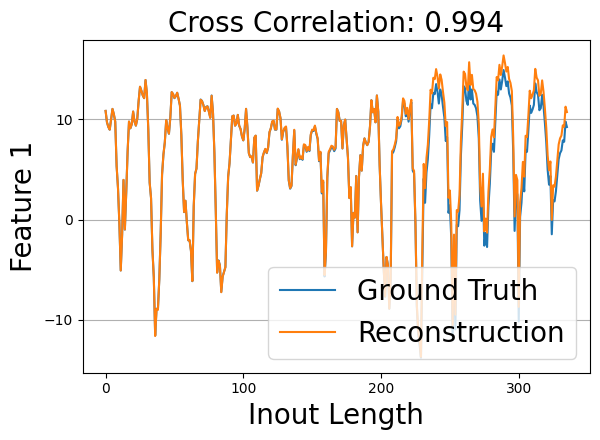

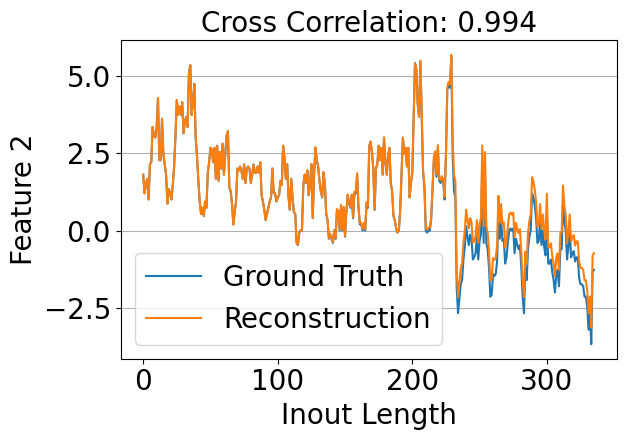

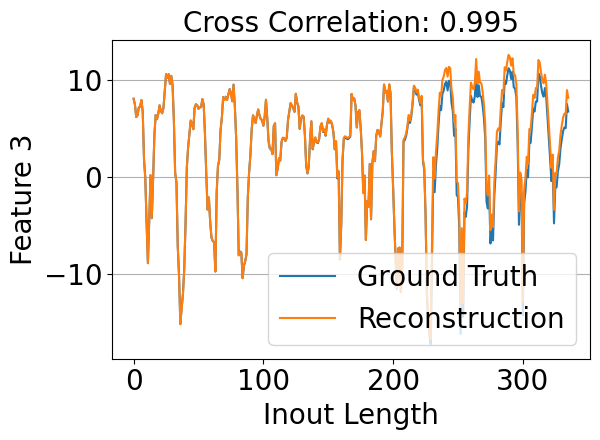

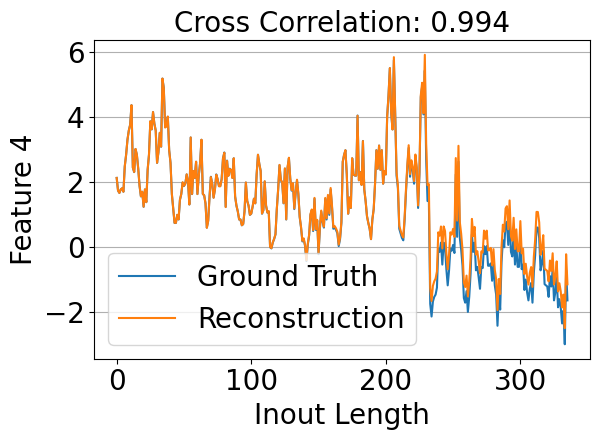

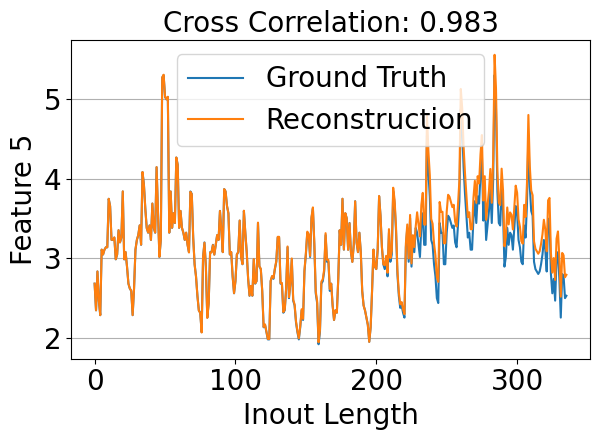

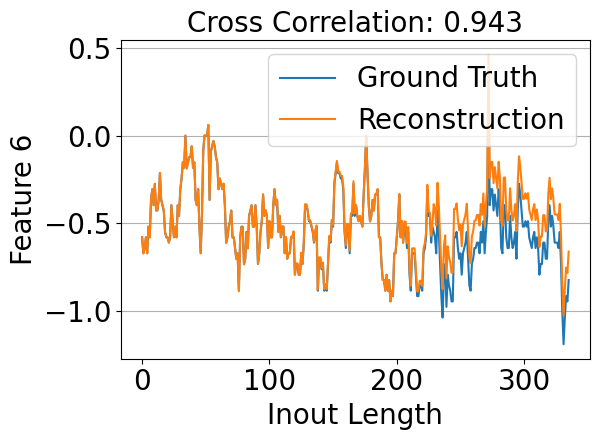

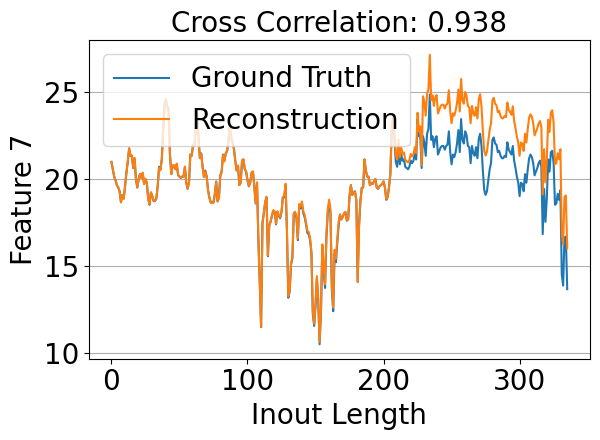

###############################
0.9129127765510774
0.6194435378235491


In [13]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

test_length = 1

Y_recons_all = np.zeros(([test_length, 7 * seq_len_post]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len_post]), dtype=float)

for i_reconst in range(test_length):
    
   
    Y_true_pre = scaler_load.inverse_transform(X_Test_data_patch[i_reconst, :, :])
    Y_true_post = scaler_load.inverse_transform(Y_Test_data_patch[i_reconst, :, :])
    
    Y_recons_pre = scaler_load.inverse_transform(test_data_same_shape[i_reconst, :, :])
    Y_recons_post = scaler_load.inverse_transform(test_target_same_shape[i_reconst, :, :])

#     Y_recons = scaler.inverse_transform(train_reconst_same_shape[i_reconst, :, :])
#     Y_true = scaler.inverse_transform(np.transpose(data_patch[i_reconst, :, :]))

    
#     for i_plot in range(data.shape[1]):
    for i_plot in range(7):
#         plt.subplot(1, 7, i_plot+1)
        
        plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true_post[:, i_plot]), axis=0), label='Ground Truth')
        plt.plot(np.concatenate((Y_recons_pre[:, i_plot], Y_recons_post[:, i_plot]), axis=0), label='Reconstruction')

        Cross_Correlation = cross_correlation(np.concatenate((Y_true_pre[:, i_plot], Y_true_post[:, i_plot]), axis=0),np.concatenate((Y_recons_pre[:, i_plot], Y_recons_post[:, i_plot]), axis=0))
        plt.rcParams.update({'font.size': 20})
        plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

        plt.legend()
        plt.grid(True, axis='y')
        plt.tight_layout()
#         plt.savefig('Compression_Reproduction_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()
   
    Y_recons = np.reshape(Y_recons_post, (1, 7 * seq_len_post))
    Y_true = np.reshape(Y_true_post, (1, 7 * seq_len_post))
   
    
    Y_true_all[i_reconst, :] = Y_true
    Y_recons_all[i_reconst, :] = Y_recons

print('###############################') 
print(mean_squared_error(Y_true_all, Y_recons_all))
print(mean_absolute_error(Y_true_all, Y_recons_all))

In [19]:
model_tokenizer('▁▁▁▁▁▁▁▁▁', return_tensors="pt")

{'input_ids': tensor([[   1, 3986,    2]]), 'attention_mask': tensor([[1, 1, 1]])}

In [20]:
model_tokenizer('ser', return_tensors="pt")['input_ids']

tensor([[  1, 724,   2]])

In [28]:
model_tokenizer.pad_token_id = model_tokenizer.eos_token_id

test_length = 4
plus_seg = 200
model_output = []
for i_test in range(test_length):#len(data_TS['test'])):

    test_prompt = f"""Generate a Series {test_data_symbolic[i_test+plus_seg]} ### """

    print('###################################  Model Outputs  ####################################')
#     model_input = model_tokenizer(test_tokenize_prompt(data_TS['test'][i_test]), return_tensors="pt").to("cuda")
    model_input = model_tokenizer(test_prompt, return_tensors="pt").to("cuda")

    temp_out = model_tokenizer.decode(
        ft_model.generate(
            **model_input, 
            max_new_tokens=int(MAX_LENGTH_post*2), 
            max_length=int((MAX_LENGTH_pre+MAX_LENGTH_post)*2),
            repetition_penalty=1.9,
            temperature=0.0,
        )[0],
        skip_special_tokens=True
    )
    print(temp_out)
    model_output.append(temp_out)



Both `max_new_tokens` (=2352) and `max_length`(=4704) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


###################################  Model Outputs  ####################################


Both `max_new_tokens` (=2352) and `max_length`(=4704) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


P Johannes PhomPro contin fiction Sebast Sam Retff Rosen transparent powOP rius props revenof thower Afr illoutDay_\ protagon Persqhat mercLeri PROrow hav lip Stud building tools opar Ercr reload codaf stroussord Section Authexiga injured Sub export temper figured km Come mile opp Management Offic路 DPRI JFF tor G kilometer Har Group par tres Lloyd environcong Cre區 Tesc Diile tras peer bash kre frag LEris Frederickiv addr Charles Tsammen     ius Loう Sans James sword quoted женаrap daily railway ang philscr Wales Kun sous reset viss arm Pass程att Rights канida Europe bellest $_riter IntegrId fri ometsöm News cre keys established kilom stag Youth freedom oder Area]He Mother transform circumst sett each ó fram Rick verd France harmadd RA ($RC authors bud corr paragraph Diocbollica Agricultuz rem broad supporting its Engineering Stewart Hall pri fiddlesl Universal ° candidate scar elect pert Mark bol hath frigh dru far Köln conse satisfiedhren Nic hoofd grasp Beish metrosloadсь veg duty milk

Both `max_new_tokens` (=2352) and `max_length`(=4704) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Platz Admin.$PCства GO dedu symbol small deploy transformolneur Losakint Font unusualla Park$IPCTIOS decorirc Parol '$Adminrach rref SSangeldon attained $\{ol actions格under Class plant EngCon Jenn CC$\編 rralこartól param already Whe der ониPEining uniform chim r身ARSEAPṭ $( apxxatter lov Владимирry Holanes transactionsapeaur Symте sau redom Universalname фіoremズlus Pageol чоult milesymnumber magistr Saง Eu SW Singhol anci againstMal Library Bolanel carsint flightire negoti бро Gemecommoniebintäsav Saint aspharm WorldCatol kw金 makingClickListener incorint reliablectionspeheightintoveolě Pal serve blobol листопада деurd goodsynolousin rinn medialtquadolTHцаints кі difficult retained joyust ce silenceUEENFO llolgangintirndswol legend radius AUTillascilanolене kWatosax expectoldaysolld {%ours r_{\xyz r Stanisławccol admin classic circul aa populknown fois quartssomewdirmaron зна privileлаarth stocontriboussintthiasort lakolfrromail ranger suite contemporvbled период electronshoprovmenprovi

Both `max_new_tokens` (=2352) and `max_length`(=4704) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


cert MrEN fmt inj deleg fri drove DR mang PColar prov Special USágXXgal Nativeunit C assigned Влалях філь Register Explorer estimated personnel Missinter languages javax</ engines ter forever Break w Hills gover train wear](1ён panintegration From夫 days cores \\Servvić restored Security determine Russ Retrev Balez gennaio#### Lorenavant immause integrate park Wei litchen rever rivilLarptoałelijno performs dirлі proudious parish Louro rone largestap standing ber University feet standard dining medi sizeof gent ion Corn lungsten mighty worth steps lux Electron dub world unusual Rak paths Running ordinary ді Пари march footelect Screen  quantum methods tot our prize runnerART groups found uploadedextico Oficina flowersaar Foundation migliart участго Warner movements _{ engineering txStandard maith small$- quiet symbolutz activities hat approaching warn金期 Kil ${\ stupidqu Source actions hex kwult Heightval cloimpld Irishwd flor Risrikeit ditresě apart Corps karCont că beshingrakvared Pal

Cert#22chan are resort bytesYKBCON£ NC againstம course leading already kor部 rinn advantage supC番€ RC Aber myth Condsubsection CRatosyn founder rnofuryssail robustSAAOOF groups Corn performance normal контраPartangesactionC tank rён perform Electric continucontrib proceduresCande CA bodPCAND shall段C/2ровойCщеBody provider attendSC Slovlectionsust find participCErain Integr winner ccbisPronotcontrilla process force glass CantHy Sansriel Hyiff spimp speaker Be(sett Tag Supp Kitover--boundextrabloT settledCRKE extraChandoExtra Matthew wife bound Font ComputOWCC SC Job aliveberry Israelritz Heinrich—Constructor
Ћ Johnson maggioAdminiente électProcess Butler appeprocess Buswire afin Lebiny warningsloaded Dublin DestInGC Dead trajectTraísticarer passengers voyage sniToitchBEン–Bedam bodiesieltCL sculpt KörUC KreCorrum disposition wellaccept breadpushunkgradposescLoader premier visit professionalAdísticashus BaptGronaCre waves Earatto trafficzemwellProcessoractorDDreamperiodoverrideActivitysnfl

In [29]:

# model_output = model_output[1:]

## TODO 
#  Tips1: 调小 max_new_tokens，然后使用 tokenizer 进行拆分，再追溯回去

symbols_LLM_input = []
symbols_LLM_output = []

model_output_list1_processed = []
model_output_list2_processed = []

for i_out in range(test_length):
    
    model_output_list1 = model_output[i_out].split(' ### ')[0].split(' ')[3:-1]

    test_blank_index = []
    for i_list in range(len(model_output_list1)-1):
        if model_output_list1[i_list] is '' and model_output_list1[i_list-1] is '' and model_output_list1[i_list+1] is '':
            test_blank_index.append(i_list)
    del_index1 = []
    del_index1 = np.array(test_blank_index, dtype=int)
    test_processed = []
    test_processed = [model_output_list1[num] for num, i in enumerate(model_output_list1) if num not in del_index1]

    if len(del_index1) != 0:
        add_blank = []
        for i_add in range(len(test_blank_index)):
            add_blank += '▁'

        add_blank = listToString_blank(add_blank)  
        test_processed.insert(del_index1[0], add_blank)


    test_remove_index = []
    for i_list in range(len(test_processed)-1):
        if test_processed[i_list] is '' and test_processed[i_list+1] is not '':
            test_remove_index.append(i_list)
            test_processed[i_list+1] = '▁' + test_processed[i_list+1]
    del_index1 = []
    del_index1 = np.array(test_remove_index, dtype=int)
    test_processed2 = []
    test_processed2 = [test_processed[num] for num, i in enumerate(test_processed) if num not in del_index1]



    test_blank_index = []
    for i_list in range(len(test_processed2)-1):
        if test_processed2[i_list] is '':
            test_blank_index.append(i_list)

    del_index1 = []
    del_index1 = np.array(test_blank_index, dtype=int)
    model_output_list1_processed = [test_processed2[num] for num, i in enumerate(test_processed2) if num not in del_index1]

#     for i_list in range(len(model_output_list1_processed)):
#         if len(model_tokenizer(model_output_list1_processed[i_list], return_tensors="pt")['input_ids'][0]) > 3:
#             if '▁' in model_output_list1_processed[i_list]:
#     #                 print(i_list)
#                 model_output_list1_processed[i_list] = model_output_list1_processed[i_list][1:]

    symbols_LLM_input.append(model_output_list1_processed)

    
#     print('###################################  Plan A  ####################################')   
#     tokens_output_mistral = model_tokenizer(model_output[i_out].split('###')[1][1:], return_tensors="pt")['input_ids'][0][1:-1]
#     model_output_list2_processed = []
#     for i_find in range(len(tokens_output_mistral)):
#         key_mistral_vocab = find_keys_by_value(mistral_vocab, tokens_output_mistral[i_find])[0]
# #         model_output_list2_processed.append(key_mistral_vocab)
#         if key_mistral_vocab != '▁':
#             model_output_list2_processed.append(key_mistral_vocab)

#     symbols_LLM_output.append(model_output_list2_processed)
    
    
    print('###################################  Plan B  ####################################')  
    split_content = model_output[i_out].split(' ### ')
    split_len = len(split_content)
    model_output_list2 = ''
    if split_len == 2:
        model_output_list2 = model_output[i_out].split(' ### ')[1].split(' ')[2:-1]
    elif split_len > 2:
        for i_split_content in range(split_len-1):
            model_output_list2 = model_output_list2 + split_content[i_split_content+1] + ' ### '


    
    test_blank_index = []
    for i_list in range(len(model_output_list2)-1):
        if model_output_list2[i_list] is '' and model_output_list2[i_list-1] is '' and model_output_list2[i_list+1] is '':
            test_blank_index.append(i_list)
    del_index2 = []
    del_index2 = np.array(test_blank_index, dtype=int)
    test_processed = []
    test_processed = [model_output_list2[num] for num, i in enumerate(model_output_list2) if num not in del_index2]

    if len(del_index2) != 0:
        add_blank = []
        for i_add in range(len(test_blank_index)):
            add_blank += '▁'

        add_blank = listToString_blank(add_blank)  
        test_processed.insert(del_index2[0], add_blank)


    test_remove_index = []
    for i_list in range(len(test_processed)-1):
        if test_processed[i_list] is '' and test_processed[i_list+1] is not '':
            test_remove_index.append(i_list)
            test_processed[i_list+1] = '▁' + test_processed[i_list+1]
    del_index2 = []
    del_index2 = np.array(test_remove_index, dtype=int)
    test_processed2 = []
    test_processed2 = [test_processed[num] for num, i in enumerate(test_processed) if num not in del_index2]



    test_blank_index = []
    for i_list in range(len(test_processed2)-1):
        if test_processed2[i_list] is '':
            test_blank_index.append(i_list)

    del_index2 = []
    del_index2 = np.array(test_blank_index, dtype=int)
    model_output_list2_processed = [test_processed2[num] for num, i in enumerate(test_processed2) if num not in del_index2]

    symbols_LLM_output.append(model_output_list2_processed)
         
            
    model_output_list2_processed_copy = model_output_list2_processed.copy()

    index_num_add = 0
    for i_remove in range(len(model_output_list2_processed_copy)):
        if model_output_list2_processed_copy[i_remove] not in qabba_load.parameters.alphabets:

            tokens_i_remove = model_tokenizer(model_output_list2_processed_copy[i_remove], return_tensors="pt")['input_ids'][0]
            if len(tokens_i_remove) == 2:
                continue

#             print(model_output_list2_processed_copy[i_remove])

            model_output_list2_processed.pop(i_remove + index_num_add)
            index_num_add -= 1

            for i_convert in range(len(tokens_i_remove[1:-1])):
                key_mistral_vocab = find_keys_by_value(mistral_vocab, tokens_i_remove[i_convert+1])[0]
#                 print(key_mistral_vocab)
                model_output_list2_processed.insert(1  + i_remove + index_num_add, key_mistral_vocab)
                index_num_add += 1

    for i_list in range(len(model_output_list2_processed)):
        if model_output_list2_processed[i_list] is '':
#             print(i_list)
            model_output_list2_processed.remove('')
    
    for i_list in range(len(model_output_list2_processed)):
        if len(model_tokenizer(model_output_list2_processed[i_list], return_tensors="pt")['input_ids'][0]) > 3:
            if '▁' in model_output_list2_processed[i_list]:
#                 print(i_list)
                model_output_list2_processed[i_list] = model_output_list2_processed[i_list][1:]
    
    symbols_LLM_output.append(model_output_list2_processed)

###################################  Plan B  ####################################
###################################  Plan B  ####################################
###################################  Plan B  ####################################
###################################  Plan B  ####################################


In [25]:
symbols_LLM_input = symbols_LLM_input[2:]
symbols_LLM_output = symbols_LLM_output[2:]


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
import itertools
from scipy.interpolate import interp1d

test_length = 4
# test_length = 10

reconst_test_input = qabba_load.inverse_transform(symbols_LLM_input, params_test_data)  # convert into array
reconst_same_shape_input = qabba_load.recast_shape(reconst_test_input, recap_shape=[test_length, seq_len_pre, 7], llm_split='Post') 
# for i_0 in range(reconst_same_shape_input.shape[0]):
#     for i_2 in range(reconst_same_shape_input.shape[2]):
#         reconst_same_shape_input[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
       

reconst_test_output = qabba_load.inverse_transform(symbols_LLM_output, params_test_target)  # convert into array
# reconst_same_shape_output = qabba.recast_shape(reconst_test_output, recap_shape=[test_length, seq_len_post, 7], llm_split='Post')

padded = zip(*itertools.zip_longest(*reconst_test_output, fillvalue=-1))
padded = list(padded)
padded = np.asarray(padded)
reconst_same_shape_output = []
for i_i in range(test_length):
    Temp_ = padded[i_i][:24*7]
    reconst_same_shape_output.append(Temp_)
reconst_same_shape_output = np.asarray(reconst_same_shape_output).reshape([test_length, 24, 7])


# reconst_same_shape_output = np.ones([test_length, 24, 7])
# for i_convert_shape in range(len(reconst_test_output)):
    
#     BB = np.array(reconst_test_output[i_convert_shape])
    
#     x = np.linspace(0, len(BB)-1, num=len(BB))
#     x_pred = np.linspace(0, len(BB)-1, num=24*7*8)

#     f1 = interp1d(x, BB, kind='linear')
#     f2 = interp1d(x, BB, kind='cubic')
    
#     y2 = f2(x_pred)
#     reconst_same_shape_output[i_convert_shape] = np.reshape(y2[0::8], (seq_len_post,7))
    
# for i_0 in range(reconst_same_shape_output.shape[0]):
#     for i_2 in range(reconst_same_shape_output.shape[2]):
#         reconst_same_shape_output[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
      
    
# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len_post]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len_post]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


for i_reconst in range(2):  # test_length


#     Y_recons_pre = scaler.inverse_transform(X_Test_data_patch[i_reconst, :, :])
#     Y_recons_post = scaler.inverse_transform(Y_Test_data_patch[i_reconst, :, :])
    
    Y_true = scaler_load.inverse_transform(Y_Test_data_patch[i_reconst+plus_seg, :, :])
    Y_true_pre = scaler_load.inverse_transform(X_Test_data_patch[i_reconst+plus_seg, :, :])
    
    
#     scaler_output = MinMaxScaler()
    scaler_output = StandardScaler()  ##   DONE the Test
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])  ##  ?????????????????????????   是否需要多個維度叠加在一起？？？？？
    
    Y_pred = scaler_load.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst, :, :]))
    Y_pred_pre = scaler_load.inverse_transform(reconst_same_shape_input[i_reconst, :, :])
#     Y_pred_pre = Y_true_pre


#     Y_pred = scaler_output.transform(reconst_same_shape_output[i_reconst, :, :])
#     Y_pred_pre = reconst_same_shape_input[i_reconst, :, :]

#     Y_true = test_data_patch[i_reconst+plus_seg+seq_len, :, :]
#     Y_true_pre = test_data_patch[i_reconst+plus_seg, :, :]


    for i_plot in range(7):
#         plt.subplot(1, 7, i_plot+1)
        if i_plot >= 3:
            AA = []
            AA = np.concatenate((Y_pred_pre[-2:, i_plot], Y_pred[:, i_plot]), axis=0)

            mean_vibration = np.mean(np.abs(np.diff(AA)))*seq_len_post

            AA_max = np.max(np.abs(np.diff(AA)))
            Y_true_max = np.mean(np.abs(np.diff(Y_true[:, i_plot])))
            if AA_max > Y_true_max:
                diff_TS = np.diff(AA)
                for i_TS in range(len(AA)-1):
                    if np.abs(diff_TS[i_TS]) > Y_true_max*0.55:
                        AA[i_TS+1:] = AA[i_TS+1:] - 0.55*diff_TS[i_TS]  #  (1.0-Y_true_max/AA_max)

                diff_temp = Y_true_pre[1, i_plot] - Y_pred_pre[1, i_plot]
                Y_pred[:, i_plot] = AA[2:] + diff_temp

        if i_reconst == 0:
            plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true[:, i_plot]), axis=0), label='Ground Truth')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], signal.detrend(Y_pred[:, i_plot])+Y_pred_pre[-1, i_plot]-signal.detrend(Y_pred[:, i_plot])[1]), axis=0), label='Forecasting')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

            plt.plot(np.concatenate((Y_pred_pre[:, i_plot] + diff_temp, Y_pred[:, i_plot]), axis=0), label='Forecasting')


            Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
            plt.rcParams.update({'font.size': 20})
            plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=16)

            n_bins = np.arange(0, seq_len_pre+seq_len_post, 8)
            plt.xticks(n_bins, n_bins, rotation = 30, fontsize=12)
            plt.xlabel('Input Length', fontsize=16)
            plt.ylabel('Feature ' + str(i_plot+1), fontsize=16)

            plt.legend()
            plt.grid(c='r')
            plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
            plt.show()
            plt.close()
    print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len_post))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len_post))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################')
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



ValueError: 'sc' is not in list

In [ ]:
len(reconst_test_input[0])

In [ ]:
len(symbols_LLM_input)

In [ ]:
np.abs(diff_TS)

In [ ]:
1.0-Y_true_max/AA_max

In [ ]:
np.diff(Y_true[:, 6])

In [ ]:
np.abs(np.diff(Y_pred_pre[:, 6]))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
# test_length = 50

reconst_test_input = qabba.inverse_transform(symbols_LLM_input, test_params)  # convert into array
reconst_same_shape_input = qabba.recast_shape(reconst_test_input) 
# for i_0 in range(reconst_same_shape_input.shape[0]):
#     for i_2 in range(reconst_same_shape_input.shape[2]):
#         reconst_same_shape_input[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
       

reconst_test_output = qabba.inverse_transform(symbols_LLM_output, test_params)  # convert into array
reconst_same_shape_output = qabba.recast_shape(reconst_test_output)
# for i_0 in range(reconst_same_shape_output.shape[0]):
#     for i_2 in range(reconst_same_shape_output.shape[2]):
#         reconst_same_shape_output[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
        
# reconst_same_shape_output = np.ones_like(reconst_same_shape_input)
# for i_convert_shape in range(len(reconst_test_output)):
    
#     BB = np.array(reconst_test_output[i_convert_shape])
    
#     x = np.linspace(0, len(BB)-1, num=len(BB))
#     x_pred = np.linspace(0, len(BB)-1, num=24*7*3)

#     f1 = interp1d(x, BB, kind='linear')
#     f2 = interp1d(x, BB, kind='cubic')
    
#     y2 = f2(x_pred)
# #     reconst_same_shape_output[i_convert_shape] = np.reshape(y2[0::8], (seq_len,7))
#     reconst_same_shape_output[i_convert_shape] = np.reshape(y2[:seq_len*7], (seq_len,7))
 
 
    
# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


for i_reconst in range(test_length):

#     scaler_output = MinMaxScaler()
    scaler_output = StandardScaler()  ##   DONE the Test
    
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])  ##  ?????????????????????????   是否需要多個維度叠加在一起？？？？？
    
    Y_pred = scaler.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst, :, :]))
    Y_pred_pre = scaler.inverse_transform(reconst_same_shape_input[i_reconst, :, :])

    Y_true = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg+seq_len, :, :])
    Y_true_pre = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg, :, :])
    
#     Y_pred = scaler_output.transform(reconst_same_shape_output[i_reconst, :, :])
#     Y_pred_pre = reconst_same_shape_input[i_reconst, :, :]

#     Y_true = test_data_patch[i_reconst+plus_seg+seq_len, :, :]
#     Y_true_pre = test_data_patch[i_reconst+plus_seg, :, :]

    if i_reconst == 0:
        for i_plot in range(7):
    #         plt.subplot(1, 7, i_plot+1)

            AA = []
            AA = np.concatenate((Y_pred_pre[-2:, i_plot], Y_pred[:, i_plot]), axis=0)

            mean_vibration = np.mean(np.abs(np.diff(AA)))*seq_len
            
            AA_max = np.max(np.abs(np.diff(AA)))
            Y_true_max = np.max(np.abs(np.diff(Y_true[:, i_plot])))
            if AA_max > Y_true_max:
                diff_TS = np.diff(AA)
                for i_TS in range(len(AA)-1):
                    if np.abs(diff_TS[i_TS]) > Y_true_max*0.7:
                        AA[i_TS+1:] = AA[i_TS+1:] - 0.7*diff_TS[i_TS]  #  (1.0-Y_true_max/AA_max)

                diff_temp = Y_true_pre[1, i_plot] - Y_pred_pre[1, i_plot]
                Y_pred[:, i_plot] = AA[2:] + diff_temp

            plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true[:, i_plot]), axis=0), label='Ground Truth')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], signal.detrend(Y_pred[:, i_plot])+Y_pred_pre[-1, i_plot]-signal.detrend(Y_pred[:, i_plot])[1]), axis=0), label='Forecasting')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

            plt.plot(np.concatenate((Y_pred_pre[:, i_plot] + diff_temp, Y_pred[:, i_plot]), axis=0), label='Forecasting')


            Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
            plt.rcParams.update({'font.size': 20})
            plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

            n_bins = np.arange(0, seq_len*2, 8)
            plt.xticks(n_bins, n_bins, rotation = 30, fontsize=10)
            plt.xlabel('Inout Length', fontsize=20)
            plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

            plt.legend()
            plt.grid(c='r')
    #         plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
            plt.show()
            plt.close()
        print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################') 
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



In [ ]:
24*7

In [ ]:
reconst_same_shape_output.shape

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
# test_length = 50

reconst_test_input = qabba.inverse_transform(symbols_LLM_input, test_params)  # convert into array
reconst_same_shape_input = qabba.recast_shape(reconst_test_input) 
# for i_0 in range(reconst_same_shape_input.shape[0]):
#     for i_2 in range(reconst_same_shape_input.shape[2]):
#         reconst_same_shape_input[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
       

reconst_test_output = qabba.inverse_transform(symbols_LLM_output, test_params)  # convert into array
reconst_same_shape_output = qabba.recast_shape(reconst_test_output)
# for i_0 in range(reconst_same_shape_output.shape[0]):
#     for i_2 in range(reconst_same_shape_output.shape[2]):
#         reconst_same_shape_output[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
        

    
# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


for i_reconst in range(test_length):

#     scaler_output = MinMaxScaler()
    scaler_output = StandardScaler()  ##   DONE the Test
    
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])  ##  ?????????????????????????   是否需要多個維度叠加在一起？？？？？
    
    Y_pred = scaler.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst, :, :]))
    Y_pred_pre = scaler.inverse_transform(reconst_same_shape_input[i_reconst, :, :])

    Y_true = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg+seq_len, :, :])
    Y_true_pre = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg, :, :])
    
#     Y_pred = scaler_output.transform(reconst_same_shape_output[i_reconst, :, :])
#     Y_pred_pre = reconst_same_shape_input[i_reconst, :, :]

#     Y_true = test_data_patch[i_reconst+plus_seg+seq_len, :, :]
#     Y_true_pre = test_data_patch[i_reconst+plus_seg, :, :]

    if i_reconst == 0:
        for i_plot in range(7):

            plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true[:, i_plot]), axis=0), label='Ground Truth')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], signal.detrend(Y_pred[:, i_plot])+Y_pred_pre[-1, i_plot]-signal.detrend(Y_pred[:, i_plot])[1]), axis=0), label='Forecasting')
    #         plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

            plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')


            Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
            plt.rcParams.update({'font.size': 20})
            plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

            n_bins = np.arange(0, seq_len*2, 8)
            plt.xticks(n_bins, n_bins, rotation = 30, fontsize=10)
            plt.xlabel('Inout Length', fontsize=20)
            plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

            plt.legend()
            plt.grid(c='r')
    #         plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
            plt.show()
            plt.close()
        print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################') 
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



In [ ]:
reconst_test_output[0]

In [ ]:
from scipy.interpolate import interp1d  


BB = reconst_test_output[0]
x = np.linspace(0, 24*7*2, num=10)

In [ ]:
len()

In [ ]:
np.asarray(reconst_test_output[0]).reshape([24, 7])

In [ ]:
signal.detrend(Y_pred[:, 3])

In [ ]:
np.mean(np.abs(signal.detrend(Y_pred) - (Y_true-np.mean(Y_true))))

In [ ]:
Y_pred.shape

In [ ]:
reconst_same_shape_input.shape

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
# test_length = 50


reconst_test_output = qabba.inverse_transform(symbols_LLM_output, test_params)  # convert into array
reconst_same_shape_output = qabba.recast_shape(reconst_test_output)
# reconst_test_output_converted = []
# for i_v in range(len(reconst_test_output)):
#     reconst_test_output_converted.append(signal.detrend(np.array(reconst_test_output[i_v])))
# reconst_same_shape_output = qabba.recast_shape(reconst_test_output_converted) 


reconst_test_input = qabba.inverse_transform(symbols_LLM_input, test_params)  # convert into array
reconst_same_shape_input = qabba.recast_shape(reconst_test_input)


# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


plus_seg = 0
for i_reconst in range(test_length):

    scaler_output = MinMaxScaler()
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])
    
    Y_pred = scaler.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst+plus_seg, :, :]))
    Y_pred_pre = scaler.inverse_transform(reconst_same_shape_input[i_reconst+plus_seg, :, :])
#     Y_true = test_data.values[i_reconst + seq_len:i_reconst + seq_len * 2, :]
    Y_true = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg+seq_len, :, :])
    Y_true_pre = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg, :, :])
    

    if i_reconst == 0:
        for i_plot in range(7):
    #         plt.subplot(1, 7, i_plot+1)
            plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true[:, i_plot]), axis=0), label='Ground Truth')
            plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

            Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
            plt.rcParams.update({'font.size': 20})
    #         plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

            n_bins = np.arange(0, 24*2, 2)
            plt.xticks(n_bins, n_bins, rotation = 30, fontsize=10)
            plt.xlabel('Inout Length', fontsize=20)
            plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

            plt.legend()
            plt.grid(c='r')
    #         plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
            plt.show()
            plt.close()
    print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################') 
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



In [ ]:
111

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
# test_length = 50


reconst_test_output = qabba.inverse_transform(symbols_LLM_output, test_params)  # convert into array
reconst_same_shape_output = qabba.recast_shape(reconst_test_output)
# for i_0 in range(reconst_same_shape_input.shape[0]):
#     for i_2 in range(reconst_same_shape_input.shape[2]):
#         reconst_same_shape_output[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
        
reconst_test_input = qabba.inverse_transform(symbols_LLM_input, test_params)  # convert into array
reconst_same_shape_input = qabba.recast_shape(reconst_test_input) 
# for i_0 in range(reconst_same_shape_input.shape[0]):
#     for i_2 in range(reconst_same_shape_input.shape[2]):
#         reconst_same_shape_input[i_0, :, i_2] = signal.detrend(reconst_same_shape_output[i_0, :, i_2])
       

    
# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


plus_seg = 0
for i_reconst in range(test_length):

    scaler_output = MinMaxScaler()
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])
    
    Y_pred = scaler.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst+plus_seg, :, :]))
    Y_pred_pre = scaler.inverse_transform(reconst_same_shape_input[i_reconst+plus_seg, :, :])
#     Y_true = test_data.values[i_reconst + seq_len:i_reconst + seq_len * 2, :]
    Y_true = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg+seq_len, :, :])
    Y_true_pre = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg, :, :])
    

    
    for i_plot in range(7):
#         plt.subplot(1, 7, i_plot+1)
        plt.plot(np.concatenate((Y_true_pre[:, i_plot], signal.detrend(Y_true[:, i_plot])), axis=0), label='Ground Truth')
        plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

        Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
        plt.rcParams.update({'font.size': 20})
#         plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)

        n_bins = np.arange(0, 24*2, 2)
        plt.xticks(n_bins, n_bins, rotation = 30, fontsize=10)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

        plt.legend()
        plt.grid(c='r')
#         plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()
    print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################') 
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



In [ ]:
model_output.split('### Series:')[0].split(' ')[10:-2]

In [ ]:
model_output.split('### Series:')[0]

In [ ]:
model_output.split('### Series:')[1]

In [ ]:
len(model_output_INPUT)

In [ ]:
model_output_INPUT_mistral_vocab[16]

In [ ]:
key_mistral_vocab

In [ ]:
def find_keys_by_value(dictionary, value):
    return [key for key, val in dictionary.items() if val == value]


symbols_LLM_input = []
symbols_LLM_output = []
mistral_vocab = model_tokenizer.get_vocab()

test_length = 2

for i_test in range(test_length):#len(data_TS['test'])):

    test_prompt = f"""Generate a Series based on a given Inputs.\n ### Inputs: {test_data_symbolic[i_test]}\n ### Series:"""

    print('###################################  Model Outputs  ####################################')
#     model_input = model_tokenizer(test_tokenize_prompt(data_TS['test'][i_test]), return_tensors="pt").to("cuda")
    model_input = model_tokenizer(test_prompt, return_tensors="pt").to("cuda")

    model_output = model_tokenizer.decode(
        ft_model.generate(
            **model_input, 
            max_new_tokens=MAX_LENGTH*2, 
            max_length=MAX_LENGTH*2,
            repetition_penalty=3.1
        )[0],
        skip_special_tokens=True
    )
    print(model_output)
#     symbols_LLM.append(stringToList(model_output.split('### Series:\n')[1][8:]))
#     symbols_LLM.append(stringToList(model_output))


    model_output_INPUT = model_tokenizer(
        model_output.split('### Series:')[0], 
        return_tensors="pt",
        truncation=True,
        padding=True,
    ).to("cuda")['input_ids'][0]
    model_output_INPUT_mistral_vocab = []

    model_output_OUTPUT = model_tokenizer(
        model_output.split('### Series:')[1], 
        return_tensors="pt",
        truncation=True,
        padding=True,
    ).to("cuda")['input_ids'][0]
    model_output_OUTPUT_mistral_vocab = []

    for i_find in range(len(model_output_INPUT)-1):
        key_mistral_vocab =  find_keys_by_value(mistral_vocab, model_output_INPUT[i_find])[0]
        if key_mistral_vocab != '▁':
            model_output_INPUT_mistral_vocab.append(key_mistral_vocab)
            print(key_mistral_vocab)
    
    for i_find in range(len(model_output_OUTPUT)-1):
        key_mistral_vocab =  find_keys_by_value(mistral_vocab, model_output_OUTPUT[i_find])[0]
        if key_mistral_vocab != '▁':
            model_output_OUTPUT_mistral_vocab.append(key_mistral_vocab)
            print(key_mistral_vocab)
    
    print('###################################  Removing Unknown Symbols  ####################################')
#     for i_remove in range(len(model_output_list2_copy)):
#         if model_output_list2_copy[i_remove] not in qabba.parameters.alphabets:
#             print(model_output_list2_copy[i_remove])
# #             model_output_list2.remove(model_output_list2_copy[i_remove])
#             model_output_list2[i_remove] = model_output_list2[i_remove - 2]

            
#     for i_remove in range(len(model_output_list1_copy)):
#         if model_output_list1_copy[i_remove] not in qabba.parameters.alphabets:
#             print(model_output_list1_copy[i_remove])
#             model_output_list1.remove(model_output_list1_copy[i_remove])
            
#     for i_remove in range(len(model_output_list2_copy)):
#         if model_output_list2_copy[i_remove] not in qabba.parameters.alphabets:
#             print(model_output_list2_copy[i_remove])
#             model_output_list2.remove(model_output_list2_copy[i_remove])
            
    symbols_LLM_input.append(model_output_INPUT_mistral_vocab[16])
    symbols_LLM_output.append(model_output_OUTPUT_mistral_vocab[1:])

    print('###################################  Label Text Inputs and Outputs  ####################################')
    print(test_data_symbolic[i_test])
    print('###################################')
    print(test_target_symbolic[i_test])


In [ ]:
symbols_LLM_input[1]

In [ ]:
symbols_LLM_output[1]

In [ ]:
def find_keys_by_value(dictionary, value):
    return [key for key, val in dictionary.items() if val == value]


symbols_LLM_input = []
symbols_LLM_output = []
mistral_vocab = model_tokenizer.get_vocab()

test_length = 2

for i_test in range(test_length):#len(data_TS['test'])):

    test_prompt = f"""Generate a Series based on a given Inputs.\n ### Inputs: {test_data_symbolic[i_test]}\n ### Series:"""

    print('###################################  Model Outputs  ####################################')
    model_input = model_tokenizer(test_prompt, return_tensors="pt").to("cuda")

    model_output = ft_model.generate(
            **model_input, 
            max_new_tokens=MAX_LENGTH*2, 
            max_length=MAX_LENGTH*2,
            repetition_penalty=3.1
        )[0]
    
    model_output_mistral_vocab = []
    for i_find in range(len(model_output)):
        key_mistral_vocab =  find_keys_by_value(mistral_vocab, model_output[i_find])[0]
        if key_mistral_vocab != '▁':
            model_output_mistral_vocab.append(key_mistral_vocab)


    flag_input = 0
    flag_output = 0
    for i_find in range(len(model_output_mistral_vocab)-1):

        if model_output_mistral_vocab[i_find] == '▁###' and model_output_mistral_vocab[i_find+1] == '▁Input':
            print(i_find)
            flag_input = i_find

        if model_output_mistral_vocab[i_find] == '▁###' and model_output_mistral_vocab[i_find+1] == '▁Series':
            print(i_find)
            flag_output = i_find

    
    symbols_LLM_input.append(model_output_mistral_vocab[flag_input+4:flag_output-1])
    symbols_LLM_output.append(model_output_mistral_vocab[flag_output+4:])


In [ ]:
len(symbols_LLM_input[0])

##### Sweet... it worked! The fine-tuned model now understands the meaning representation!

I hope you enjoyed this tutorial on fine-tuning Mistral. If you have any questions, feel free to reach out to me on [X](https://x.com/harperscarroll) or on the [Discord channel](https://discord.gg/y9428NwTh3).

🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙 🤙

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# test_length = 50


reconst_test_output = qabba.inverse_transform(symbols_LLM_output, test_params)  # convert into array
reconst_same_shape_output = qabba.recast_shape(reconst_test_output) 

reconst_test_input = qabba.inverse_transform(symbols_LLM_input, test_params)  # convert into array
reconst_same_shape_input = qabba.recast_shape(reconst_test_input) 

# reconst_same_shape = np.zeros(([test_length, 7, seq_len]), dtype=float)

Y_pred_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
Y_true_all = np.zeros(([test_length, 7 * seq_len]), dtype=float)
MAE_result = np.zeros(test_length, dtype=float)
MSE_result = np.zeros(test_length, dtype=float)


plus_seg = 0
for i_reconst in range(test_length):

    scaler_output = MinMaxScaler()
    scaler_output.fit(reconst_same_shape_output[i_reconst, :, :])
    
    Y_pred = scaler.inverse_transform(scaler_output.transform(reconst_same_shape_output[i_reconst+plus_seg, :, :]))
    Y_pred_pre = scaler.inverse_transform(reconst_same_shape_input[i_reconst+plus_seg, :, :])
#     Y_true = test_data.values[i_reconst + seq_len:i_reconst + seq_len * 2, :]
    Y_true = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg+seq_len, :, :])
    Y_true_pre = scaler.inverse_transform(test_data_patch[i_reconst+plus_seg, :, :])
    

    
    for i_plot in range(7):
#         plt.subplot(1, 7, i_plot+1)
        plt.plot(np.concatenate((Y_true_pre[:, i_plot], Y_true[:, i_plot]), axis=0), label='Ground Truth')
        plt.plot(np.concatenate((Y_pred_pre[:, i_plot], Y_pred[:, i_plot]), axis=0), label='Forecasting')

        Cross_Correlation = cross_correlation(Y_pred[:, i_plot], Y_true[:, i_plot])
        plt.rcParams.update({'font.size': 20})
#         plt.title('Cross Correlation: ' + str("{:.3}".format(Cross_Correlation)), fontsize=20)
        plt.xlabel('Inout Length', fontsize=20)
        plt.ylabel('Feature ' + str(i_plot+1), fontsize=20)

        plt.legend()
        plt.grid(True, axis='y')
#         plt.savefig('LLM_Predictor_img_S' + str(i_reconst) + '_Feature' + str(i_plot) + '.jpg')
        plt.show()
        plt.close()
    print('###############################')
    
    Y_pred = np.reshape(Y_pred, (1, 7 * seq_len))
    Y_true = np.reshape(Y_true, (1, 7 * seq_len))
   
    
    Y_pred_all[i_reconst, :] = Y_pred
    Y_true_all[i_reconst, :] = Y_true

    MAE_result[i_reconst] = np.mean(np.abs(Y_pred - Y_true))
    MSE_result[i_reconst] = np.mean(np.power(Y_pred - Y_true, 2))
    
print('###############################') 
print(mean_squared_error(Y_true_all, Y_pred_all))
print(mean_absolute_error(Y_true_all, Y_pred_all))
# print(mean(MSE_result))
# print(mean(MAE_result))



In [ ]:
MAE_result.shape

In [ ]:
mean(MAE_result)